## Análisis de datos II - Clase 2
---

### SHAP para explicar árboles de regresión
---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import shap

### DATOS

In [2]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

In [3]:
# X, y = shap.datasets.diabetes()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_test.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
362,0.019913,0.050680,0.104809,0.070072,-0.035968,-0.026679,-0.024993,-0.002592,0.003709,0.040343
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207
435,-0.012780,-0.044642,-0.023451,-0.040099,-0.016704,0.004636,-0.017629,-0.002592,-0.038460,-0.038357
400,-0.023677,-0.044642,0.045529,0.090729,-0.018080,-0.035447,0.070730,-0.039493,-0.034522,-0.009362


### 1. Entrenamos un árbol simple

In [4]:
dtree = DecisionTreeRegressor(min_samples_split=20)
dtree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [5]:
y_pred = dtree.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²  : {r2_score(y_test, y_pred):.3f}")

MAE : 56.97
RMSE: 71.23
R²  : 0.011


**¿Cómo hace el modelo para predecir el valor para la primera observación del dataset de test?**

In [6]:
i = 0
tabla = pd.DataFrame([X_test.iloc[i]])
display(tabla)
print(f"Predicción: {y_pred[0]:.2f}")

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
362,0.019913,0.05068,0.104809,0.070072,-0.035968,-0.026679,-0.024993,-0.002592,0.003709,0.040343


Predicción: 245.22


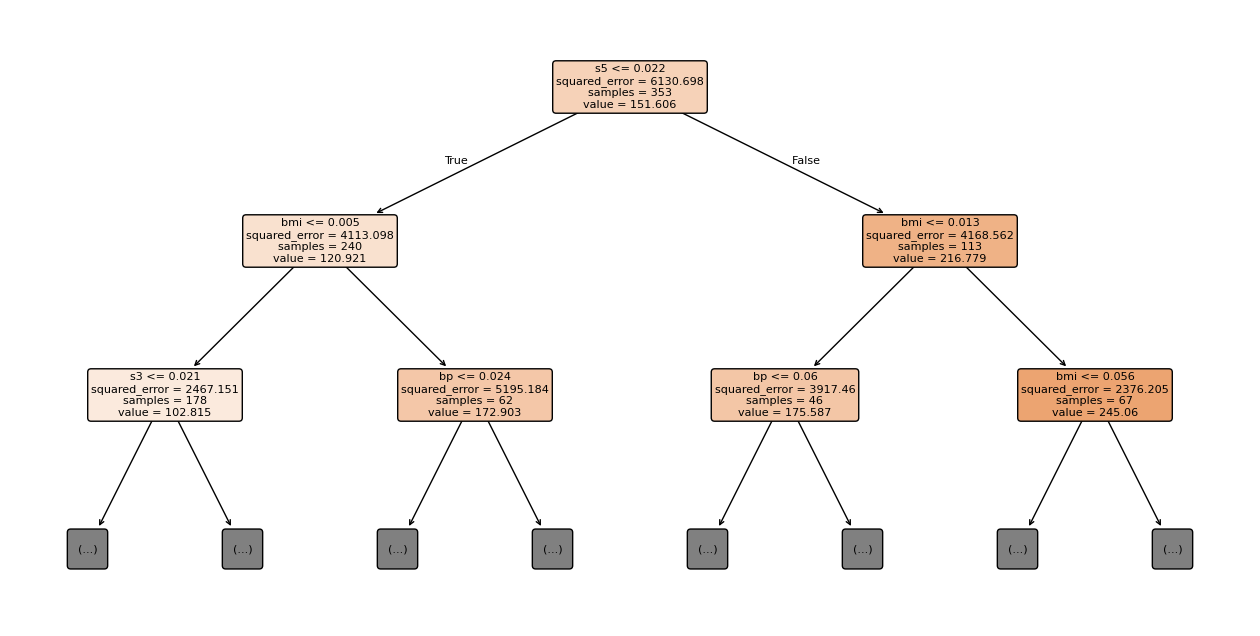

In [7]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(dtree, filled=True, feature_names=X_train.columns, rounded=True, max_depth=2, ax=ax);

El árbol toma decisiones mediante reglas.
La misma variable puede aparecer en distintos lugares y tener efectos diferentes según la región del espacio.

Veamos ahora ¿Qué variables usa más el modelo, en promedio?

In [8]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dtree.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
8,s5,0.459578
2,bmi,0.255977
3,bp,0.083196
5,s2,0.059546
6,s3,0.051726
9,s6,0.028272
0,age,0.024670
7,s4,0.015674
4,s1,0.015380
1,sex,0.005982


`feature_importances_` indica qué variables fueron más importantes para reducir el error del árbol. Es una medida global: no explica una observación particular ni indica si una variable aumenta o disminuye la predicción.

Hasta ahora vimos dos formas de entender el modelo:
1. su estructura (el árbol)
2. una medida de importancia global (feature_importances_).

Ahora vamos a ver una **tercera perspectiva**:

3. explicar una predicción individual mediante SHAP

In [9]:
explainer = shap.TreeExplainer(dtree)    # TreeExplainer() es el Explainer recomendado para árboles
explanation = explainer(X_test)

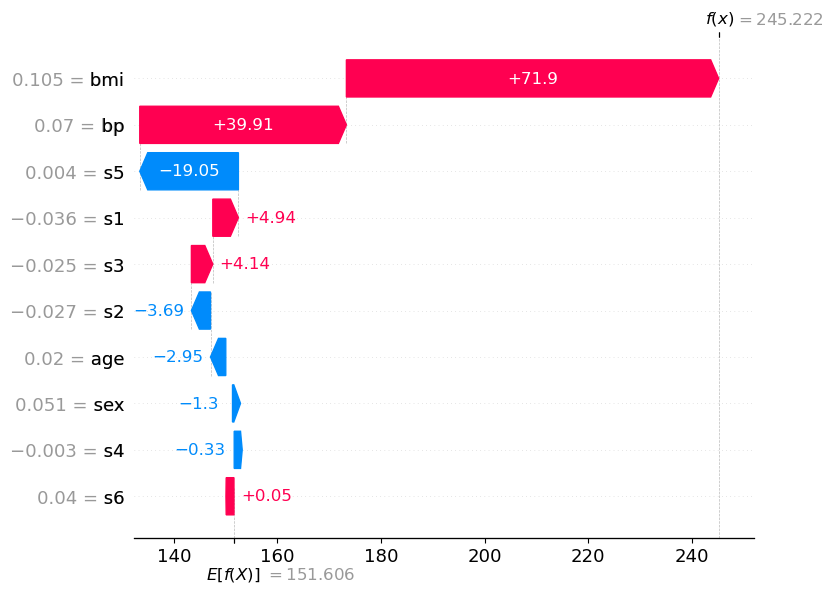

In [10]:
shap.plots.waterfall(explanation[0, :])

En un árbol, una variable no tiene un efecto fijo: su impacto depende de la región del espacio en la que se encuentre la observación.

A diferencia de feature_importances_, **SHAP**, utiliza la estructura del árbol para calcular la contribución de cada feature a una predicción individual.

Mientras `feature_importances_` responde "¿qué variables son importantes para el modelo?", SHAP responde "¿por qué el modelo hizo esta predicción en particular?".

---
## Random Forest

Un último ejemplo, SHAP con random forest.

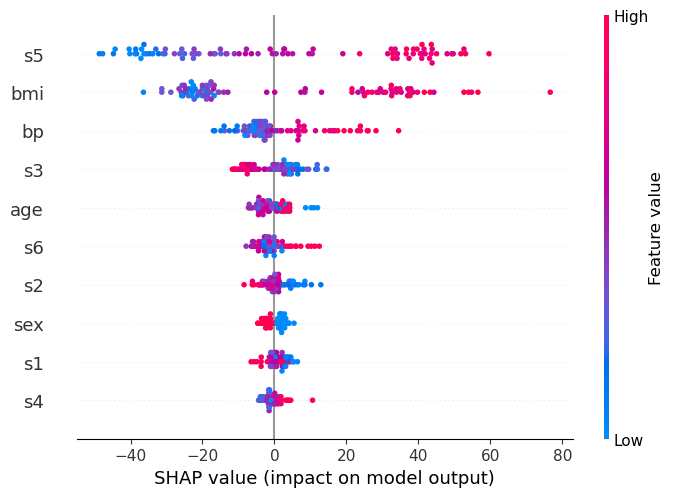

In [11]:
rforest = RandomForestRegressor(n_estimators=1000, max_depth=None, min_samples_split=2, random_state=0)
rforest.fit(X_train, y_train)

explainer = shap.TreeExplainer(rforest)  # TreeExplainer() es el Explainer recomendado para árboles.
explanation = explainer(X_test)

shap.plots.beeswarm(explanation)

**SHAP funciona aún cuando el modelo es un ensamble complejo y las contribuciones no son tan intuitivas, como en modelos más simples, como una regresión lineal o un simple árbol.**